# Telecom Customer Churn Prediction

## Business Problem

A telecom company is facing customer churn, resulting in revenue loss and additional customer acquisition costs.

The objective of this project is to build a machine learning classification model that predicts whether a customer is likely to **churn** or **stay**.

The model will estimate the probability of churn and help the company identify customers who may need proactive retention offers.

### Project Workflow
1. Load and understand the dataset
2. Clean and preprocess the data
3. Perform exploratory data analysis
4. Identify relevant features
5. Train a classification model
6. Predict churn probability
7. Classify customers as likely to churn or stay
8. Evaluate model performance
9. Interpret results in business terms
10. Suggest an improvement

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Load Dataset

In [5]:
DATA_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully.
Rows: 7043
Columns: 21


## 3. Understand the Dataset

In [6]:
display(df.head())
print("\nDataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Dataset shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [7]:
print("Data types and non-null values:")
df.info()

Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessB

In [8]:
print("Summary statistics:")
display(df.describe(include="all").T)

Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Check Data Quality

In [9]:
print("Missing values before cleaning:")
display(df.isnull().sum().to_frame("Missing Values"))

print("Duplicate rows:", df.duplicated().sum())

# TotalCharges contains blank strings in the original dataset.
blank_total_charges = (df["TotalCharges"].astype(str).str.strip() == "").sum()
print("Blank TotalCharges values:", blank_total_charges)

Missing values before cleaning:


,Missing Values
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Duplicate rows: 0
Blank TotalCharges values: 11


## 5. Data Cleaning

In [10]:
# Convert TotalCharges from text to numeric.
# Invalid/blank values become NaN.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing values after converting TotalCharges:")
display(df.isnull().sum().to_frame("Missing Values"))

# The missing TotalCharges records are very few, so remove them.
df = df.dropna(subset=["TotalCharges"]).copy()

print("Shape after cleaning:", df.shape)
print("Duplicate rows after cleaning:", df.duplicated().sum())

Missing values after converting TotalCharges:


,Missing Values
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Shape after cleaning: (7032, 21)
Duplicate rows after cleaning: 0


## 6. Target Variable Distribution

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn percentage:


,Percentage
Churn,
No,73.42
Yes,26.58


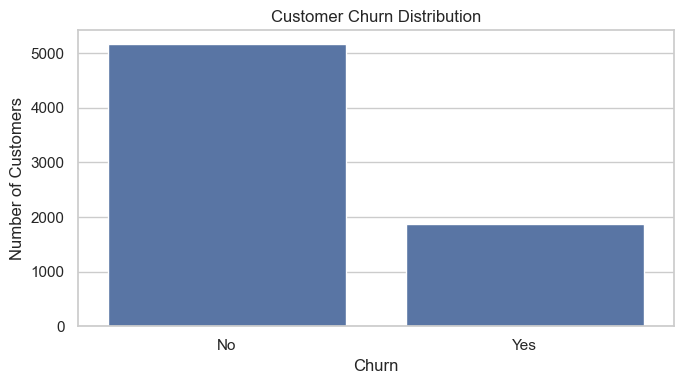

In [ ]:
import os
os.makedirs("outputs", exist_ok=True)
print(df["Churn"].value_counts())
print("\nChurn percentage:")
display(
    (df["Churn"].value_counts(normalize=True) * 100)
    .round(2)
    .to_frame("Percentage")
)
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig(
    "outputs/churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Insight

The dataset contains more non-churn customers than churn customers. This means the target classes are imbalanced, so accuracy alone should not be used to judge the model. Recall, precision, F1-score, and ROC-AUC are also important.

## 7. Exploratory Data Analysis

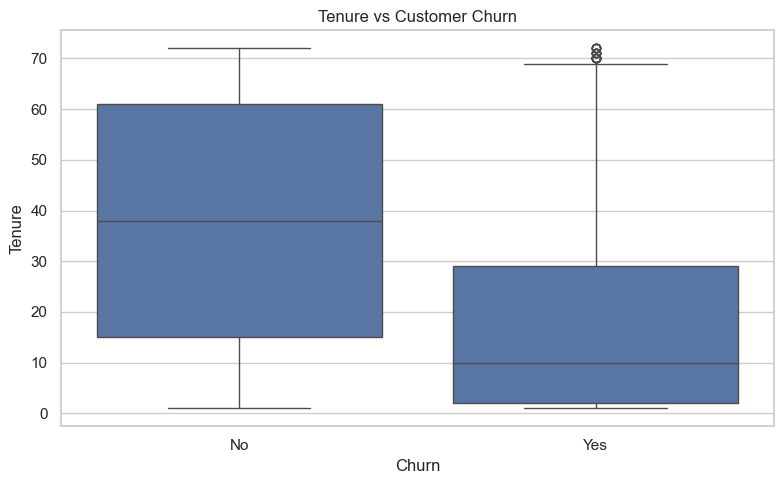

In [ ]:

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.tight_layout()
plt.show()

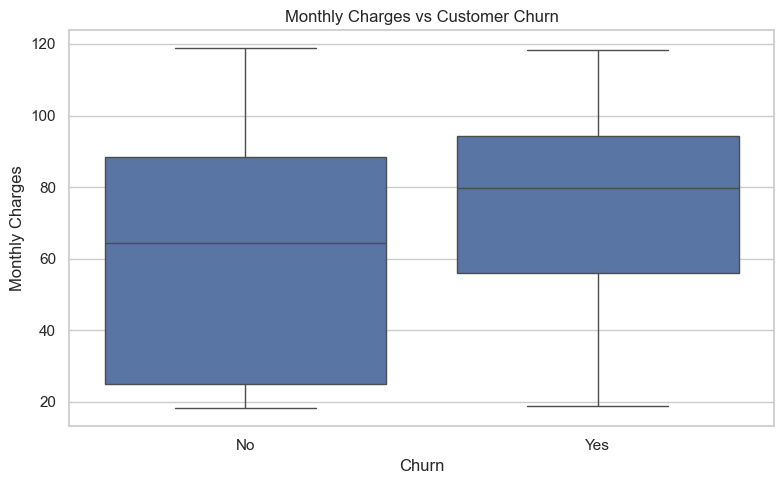

In [ ]:

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

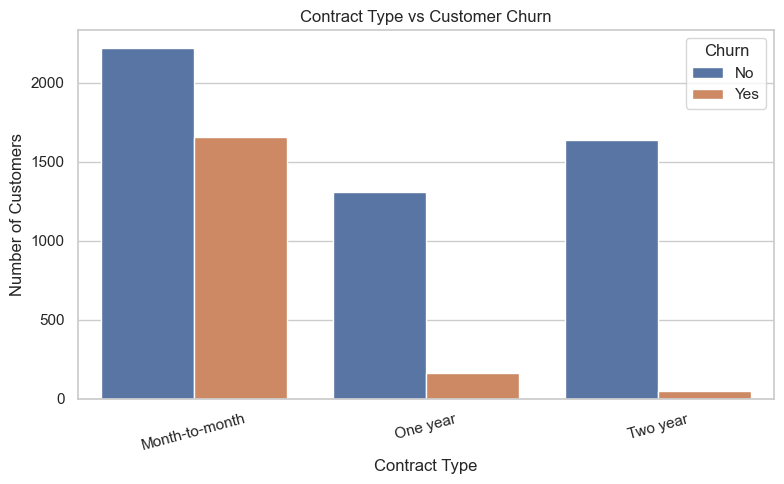

In [15]:

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

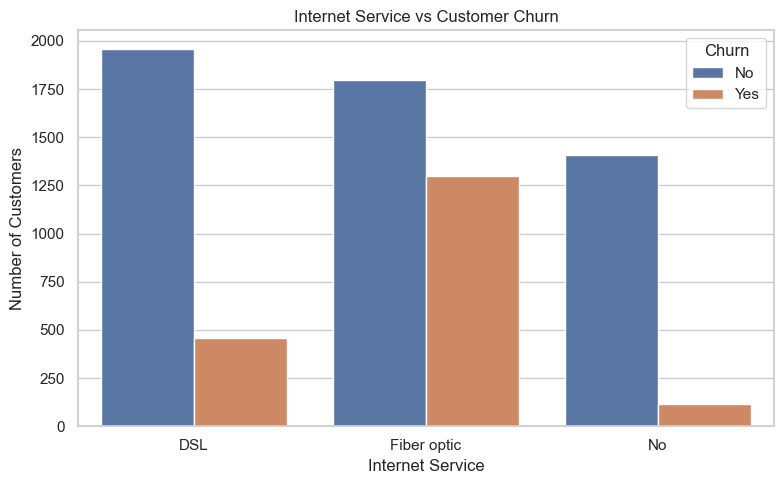

In [16]:

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Internet Service vs Customer Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

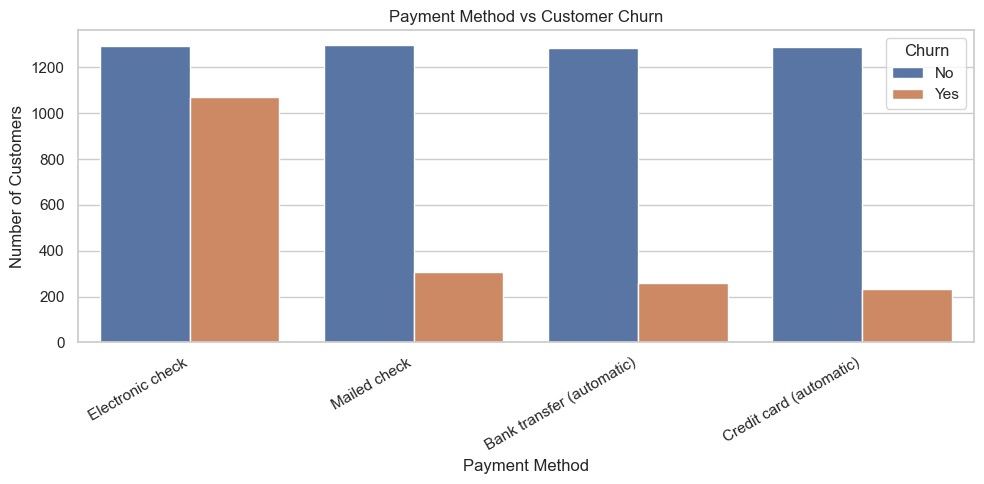

In [17]:

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.title("Payment Method vs Customer Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 8. Feature Selection

`customerID` is excluded because it is only an identifier and should not be used as a predictive feature.

The remaining customer demographic, service, contract, and billing attributes are used as model inputs.

In [18]:
X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"].map({"No": 0, "Yes": 1})

print("Input features:", X.shape[1])
print("Target distribution:")
print(y.value_counts())

Input features: 19
Target distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


## 9. Encode Categorical Features

In [ ]:
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

X = pd.get_dummies(X, columns=categorical_columns, drop_first=True)

print("\nFeature matrix shape after encoding:", X.shape)
display(X.head())

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Feature matrix shape after encoding: (7032, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


## 10. Train-Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set: (5625, 30)
Testing set: (1407, 30)

Training target distribution:
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64


## 11. Feature Scaling

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


## 12. Train Logistic Regression Model

In [22]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## 13. Predict Churn / Stay

In [23]:
# Class predictions: 0 = Stay, 1 = Churn
y_pred = model.predict(X_test_scaled)

# Probability of churn
y_probability = model.predict_proba(X_test_scaled)[:, 1]

print("First 10 predicted classes:")
print(y_pred[:10])

print("\nFirst 10 churn probabilities:")
print(np.round(y_probability[:10], 3))

First 10 predicted classes:
[0 1 0 0 0 0 0 0 1 0]

First 10 churn probabilities:
[0.017 0.595 0.005 0.2   0.1   0.47  0.027 0.164 0.686 0.015]


## 14. Model Evaluation

In [24]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_probability)

print("Model Performance")
print("-------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

Model Performance
-------------------------
Accuracy : 0.8038
Precision: 0.6476
Recall   : 0.5749
F1 Score : 0.6091
ROC-AUC  : 0.8356


In [25]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Stay", "Churn"],
    zero_division=0
))

              precision    recall  f1-score   support

        Stay       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



## 15. Confusion Matrix

In [26]:
cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

print("Confusion Matrix:")
print(cm)

print("\nBusiness interpretation:")
print("True Negatives  (TN):", TN)
print("False Positives (FP):", FP)
print("False Negatives (FN):", FN)
print("True Positives  (TP):", TP)

print("\nCorrectly identified churn customers (TP):", TP)
print("Non-churn customers misclassified as churn (FP):", FP)
print("Churn customers missed (FN):", FN)

Confusion Matrix:
[[916 117]
 [159 215]]

Business interpretation:
True Negatives  (TN): 916
False Positives (FP): 117
False Negatives (FN): 159
True Positives  (TP): 215

Correctly identified churn customers (TP): 215
Non-churn customers misclassified as churn (FP): 117
Churn customers missed (FN): 159


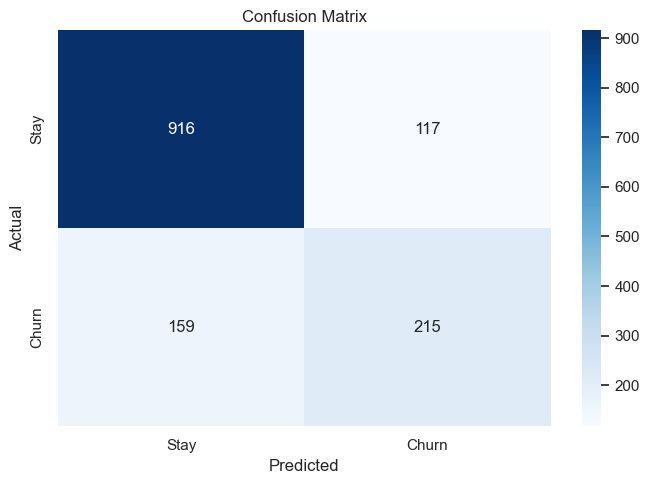

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stay", "Churn"],
    yticklabels=["Stay", "Churn"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(
    "outputs/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 16. Business Interpretation

- **True Positive (TP):** A customer who actually churned and was correctly identified.
- **False Positive (FP):** A customer who stayed but was incorrectly flagged as likely to churn. This may cause unnecessary retention costs.
- **False Negative (FN):** A customer who actually churned but was predicted to stay. This can be more costly because the company misses an opportunity to retain the customer.
- **True Negative (TN):** A customer who stayed and was correctly predicted to stay.

### Which error is more serious?

For a retention-focused business, **False Negatives are generally more serious** because they represent customers who are actually going to leave but were not identified. However, the final decision should consider the financial cost of retention offers versus the cost of losing customers.

## 17. ROC Curve

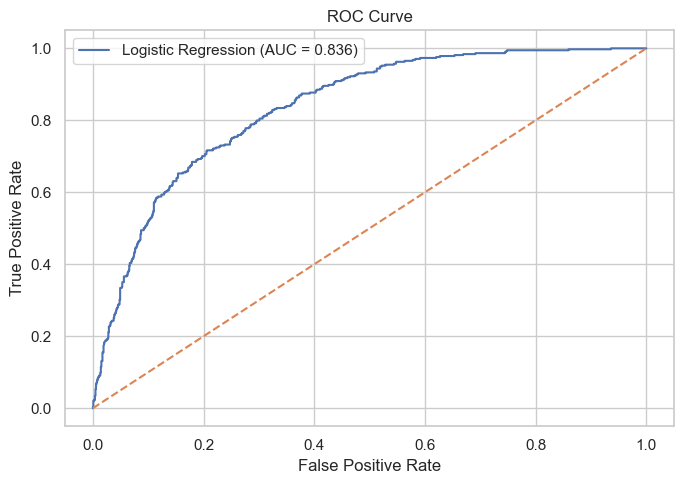

In [30]:
fpr, tpr, thresholds = roc_curve(y_test, y_probability)
plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig(
    "outputs/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 18. Feature Influence

In [31]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance["Absolute_Coefficient"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

display(feature_importance.head(15))

,Feature,Coefficient,Absolute_Coefficient
1,tenure,-1.349298,1.349298
2,MonthlyCharges,-0.849365,0.849365
10,InternetService_Fiber optic,0.725638,0.725638
3,TotalCharges,0.641556,0.641556
25,Contract_Two year,-0.601128,0.601128
24,Contract_One year,-0.311055,0.311055
21,StreamingTV_Yes,0.249341,0.249341
23,StreamingMovies_Yes,0.236012,0.236012
9,MultipleLines_Yes,0.214185,0.214185
28,PaymentMethod_Electronic check,0.182457,0.182457


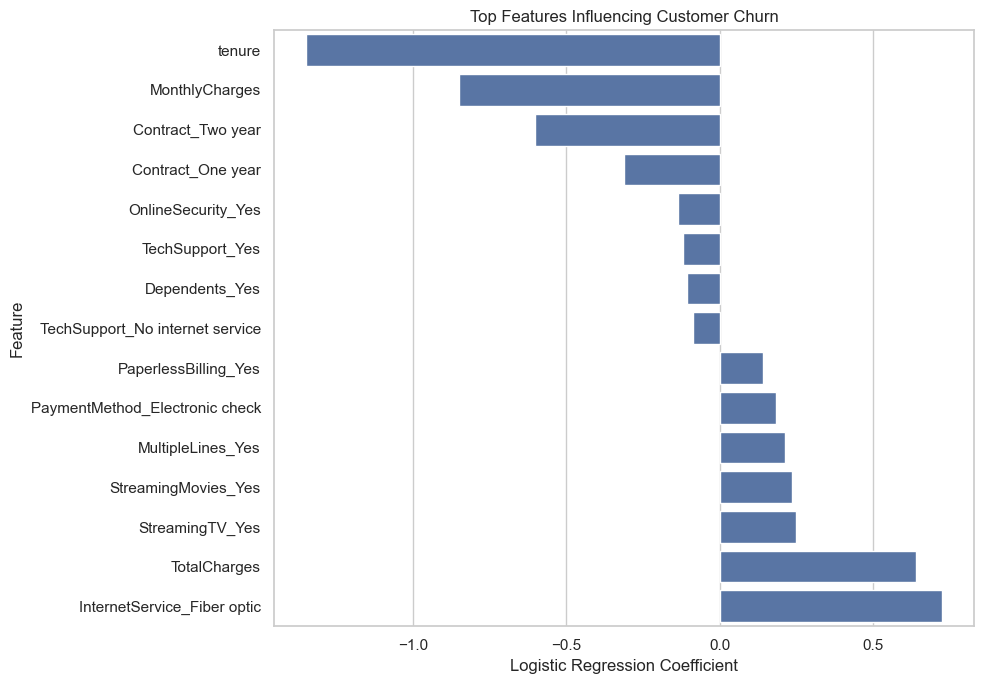

In [33]:
top_features = feature_importance.head(15).sort_values("Coefficient")
plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)
plt.title("Top Features Influencing Customer Churn")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(
    "outputs/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 19. Predict an Unseen Customer

The following example demonstrates how the trained model can estimate the churn probability of a new customer.

The customer is deliberately configured with a short tenure, a month-to-month contract, and several service/payment characteristics that may be associated with churn.

In [ ]:
new_customer = pd.DataFrame({
    "gender": ["Female"],
    "SeniorCitizen": [0],
    "Partner": ["No"],
    "Dependents": ["No"],
    "tenure": [3],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["No"],
    "DeviceProtection": ["No"],
    "TechSupport": ["No"],
    "StreamingTV": ["No"],
    "StreamingMovies": ["No"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": ["Electronic check"],
    "MonthlyCharges": [75.50],
    "TotalCharges": [226.50]
})

new_customer = pd.get_dummies(new_customer)
new_customer = new_customer.reindex(columns=X.columns, fill_value=0)

new_customer_scaled = scaler.transform(new_customer)

new_probability = model.predict_proba(new_customer_scaled)[0, 1]
new_prediction = int(new_probability >= 0.50)

print(f"Churn Probability: {new_probability:.2%}")
print("Prediction:", "Likely to Churn" if new_prediction == 1 else "Likely to Stay")

Churn Probability: 65.08%
Prediction: Likely to Churn


## 20. Threshold Improvement

In [35]:

threshold = 0.40

y_pred_40 = (y_probability >= threshold).astype(int)

print("Performance using threshold =", threshold)
print("----------------------------------------")
print(f"Accuracy : {accuracy_score(y_test, y_pred_40):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_40, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_40, zero_division=0):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_40, zero_division=0):.4f}")

Performance using threshold = 0.4
----------------------------------------
Accuracy : 0.7832
Precision: 0.5779
Recall   : 0.6845
F1 Score : 0.6267


### Improvement

Instead of always using a 0.50 probability threshold, the company can select a threshold based on business costs.

A lower threshold can increase recall and identify more potential churners, but it can also increase false positives and therefore retention campaign costs.

A stronger future version could also compare Logistic Regression with models such as Random Forest or Gradient Boosting and use cross-validation and hyperparameter tuning.

## 21. Final Business Conclusion

The developed machine learning solution predicts whether a telecom customer is likely to churn or stay based on customer demographic, service, contract, and billing information.

Logistic Regression was used as a baseline classification model because it is interpretable and provides churn probabilities. The model was evaluated using accuracy, precision, recall, F1-score, ROC-AUC, and a confusion matrix.

From a business perspective, correctly identifying churn customers allows the telecom company to provide proactive retention offers. False negatives are particularly important because they represent customers who are actually likely to leave but were not identified. Therefore, the company should pay close attention to churn recall and select a classification threshold according to the financial cost of retention offers versus customer loss.

One improvement is to optimize the classification threshold and compare additional machine learning models using cross-validation.

## 22. Save Prediction Results

In [37]:
prediction_results = pd.DataFrame({
    "Actual_Churn": y_test.values,
    "Predicted_Churn": y_pred,
    "Churn_Probability": y_probability
})

prediction_results["Actual_Label"] = prediction_results["Actual_Churn"].map({
    0: "Stay",
    1: "Churn"
})

prediction_results["Predicted_Label"] = prediction_results["Predicted_Churn"].map({
    0: "Stay",
    1: "Churn"
})

display(prediction_results.head(10))

prediction_results.to_csv(
    "outputs/churn_predictions.csv",
    index=False
)

print("Prediction results saved to outputs/churn_predictions.csv")

,Actual_Churn,Predicted_Churn,Churn_Probability,Actual_Label,Predicted_Label
0,0,0,0.017210,Stay,Stay
1,0,1,0.595304,Stay,Churn
2,0,0,0.004769,Stay,Stay
3,1,0,0.200045,Churn,Stay
4,0,0,0.100451,Stay,Stay
5,1,0,0.470355,Churn,Stay
6,0,0,0.026605,Stay,Stay
7,0,0,0.164120,Stay,Stay
8,1,1,0.686124,Churn,Churn
9,0,0,0.015229,Stay,Stay


Prediction results saved to outputs/churn_predictions.csv
